In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

In [2]:
iris = load_iris()

In [4]:
df=pd.DataFrame(iris.data, columns=iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [5]:
df = df[['petal length (cm)', 'petal width (cm)']]

print(df.head())

   petal length (cm)  petal width (cm)
0                1.4               0.2
1                1.4               0.2
2                1.3               0.2
3                1.5               0.2
4                1.4               0.2


In [6]:
scaler = MinMaxScaler()

df_scaled = scaler.fit_transform(df)

In [7]:
df_scaled = pd.DataFrame(df_scaled, columns=df.columns)

print(df_scaled.head())

   petal length (cm)  petal width (cm)
0           0.067797          0.041667
1           0.067797          0.041667
2           0.050847          0.041667
3           0.084746          0.041667
4           0.067797          0.041667


In [8]:
sse = []

In [9]:
k_range = range(1, 11)

In [10]:
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)

    km.fit(df_scaled)

    sse.append(km.inertia_)

In [11]:
print(sse)

[28.36835321972719, 5.176463590044366, 1.701874688192097, 1.1826561791866754, 0.9618843938398448, 0.6889019224531718, 0.566867830638765, 0.5416444734655237, 0.4714234315452125, 0.40230484926891924]


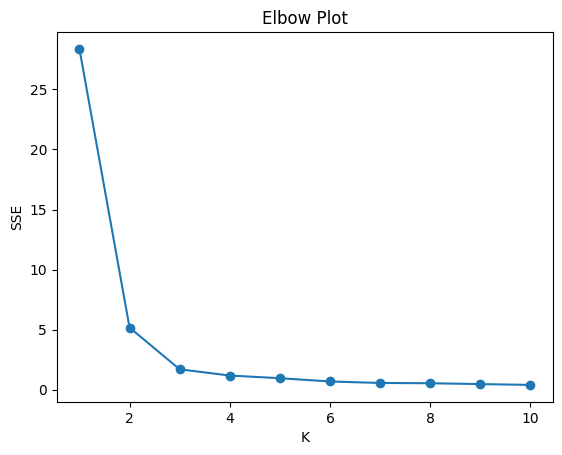

In [12]:
plt.plot(k_range, sse, marker='o')

plt.xlabel("K")
plt.ylabel("SSE")
plt.title("Elbow Plot")

plt.show()

In [13]:
km = KMeans(n_clusters=3, random_state=42)

y_pred = km.fit_predict(df_scaled)

In [14]:
df_scaled['cluster'] = y_pred

print(df_scaled.head())

   petal length (cm)  petal width (cm)  cluster
0           0.067797          0.041667        1
1           0.067797          0.041667        1
2           0.050847          0.041667        1
3           0.084746          0.041667        1
4           0.067797          0.041667        1


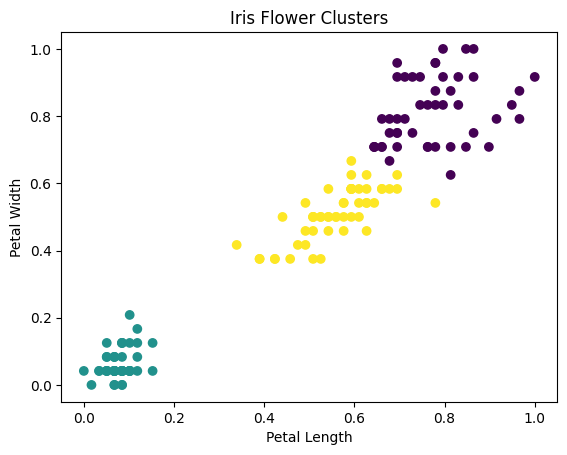

In [15]:
plt.scatter(
    df_scaled['petal length (cm)'],
    df_scaled['petal width (cm)'],
    c=df_scaled['cluster']
)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Iris Flower Clusters")

plt.show()